# Diffusion rapide 1D – Schéma volumes finis (β = 1/2)

Objectif : implémenter pas à pas un schéma volumes finis implicite en 1D pour l’équation de diffusion rapide,
et étudier le comportement des entropies discrètes au cours du temps.


## 1. Modèle continu et paramètres

On considère l'équation de diffusion rapide en 1D sur Ω = (0, 1) :

    ∂_t u = ∂_x ( u^β ∂_x u ),  avec β = 1/2

Conditions aux bords : conditions de Neumann (flux nul).  
On travaille avec un schéma volumes finis sur maillage uniforme, en temps implicite (Euler arrière).

Dans cette section, on fixe simplement les paramètres numériques : taille du maillage, pas de temps, temps final, etc.


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres globaux
beta = 0.5
L = 1.0           # longueur du domaine
N = 50            # nombre de volumes de contrôle
dx = L / N
T = 0.1           # temps final
dt = 2e-4
M = int(T / dt)   # nombre de pas de temps

# Grille : centres de mailles
x = (np.arange(N) + 0.5) * dx

print(f"N = {N}, dx = {dx:.4f}, dt = {dt}, M = {M}")


N = 50, dx = 0.0200, dt = 0.0002, M = 500


Dans cette première cellule, je fixe tous les paramètres numériques :
le domaine [0,1], le nombre de mailles N=50, le pas d’espace dx, le temps final T=0.1, le pas de temps dt, et donc le nombre de pas de temps M.
Ça me permet de vérifier que la discrétisation est raisonnable avant de coder le schéma.

## 2. Condition initiale

On définit la condition initiale utilisée dans l'article (polynôme tronqué sur un intervalle).
L'objectif ici est juste :
- de coder u0(x),
- de vérifier qu'elle ressemble à quelque chose de raisonnable graphiquement.


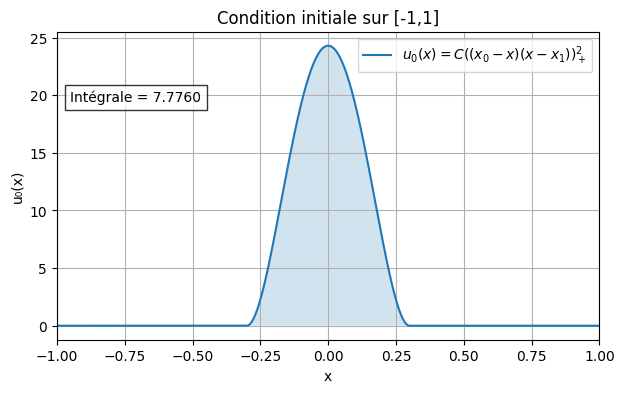

Valeur numérique de l'intégrale sur [-1,1] : 7.775999975426358


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Définition de u0
def u0(x, x0=-0.3, x1=0.3, C=3000.0):
    z = (x0 - x) * (x - x1)
    z = np.maximum(z, 0.0)
    return C * z**2

# Grille sur [-1, 1]
x = np.linspace(-1, 1, 2000)
u = u0(x)

# Calcul de l'intégrale numérique
integrale = np.trapz(u, x)

# Tracé de la courbe
plt.figure(figsize=(7,4))
plt.plot(x, u, label=r"$u_0(x) = C((x_0-x)(x-x_1))_+^2$")
plt.fill_between(x, u, alpha=0.2)   # zone sous la courbe

plt.xlim([-1, 1])
plt.xlabel("x")
plt.ylabel("u₀(x)")
plt.title("Condition initiale sur [-1,1]")
plt.grid(True)

# Affichage de l'intégrale sur la figure
plt.text(-0.95, max(u)*0.8,
         f"Intégrale = {integrale:.4f}",
         bbox=dict(facecolor='white', alpha=0.8))

plt.legend()
plt.show()

# Affichage dans la console aussi
print("Valeur numérique de l'intégrale sur [-1,1] :", integrale)


La condition initiale choisie est une fonction compacte définie par
\[
$u_0(x)$ = C $\cdot$ max (($x_0 - x$)($x - x_1$), 0)²
\]
où $(\cdot)_+$ désigne la partie positive. Cette fonction est nulle en dehors de l'intervalle
$[x_0, x_1]$ et décrit une ``bosse'' symétrique et lisse, centrée autour de $x = 0{,}5$.

Ce type de profil est classique pour tester les schémas numériques en diffusion rapide :
il est suffisamment régulier pour éviter des singularités numériques, tout en présentant un support
compact, ce qui permet d'observer clairement l'effet diffusif du modèle au cours du temps.

Le graphique obtenu montre donc une fonction initiale localisée,
qui servira de point de départ à la simulation de l'équation de diffusion rapide.


## 3. Opérateur volumes finis en espace (partie diffusion)

On factorise le schéma en séparant :
- la partie "opérateur diffusion" en espace,
- puis la discrétisation en temps.

On code d'abord une fonction qui, pour un vecteur $u_n$, renvoie les flux et la contribution spatiale.
Ici, on travaille avec la discrétisation implicite, donc on prépare quelque chose qui sera utilisé dans Newton.


In [18]:
def flux_diffusion(u, beta, dx):
    """
    Calcule les flux de diffusion aux interfaces (Neumann: flux nul aux bords).
    F_{i+1/2} = - ( (u^beta)_{i} - (u^beta)_{i-1} ) / dx
    Retourne F de taille N+1 (interfaces de 0 à N) où N = len(u).
    """
    N = len(u)
    u_beta = np.maximum(u, 0.0)**beta
    
    F = np.zeros(N+1)
    # Interfaces internes : i = 1,...,N-1
    for i in range(1, N):
        F[i] = - (u_beta[i] - u_beta[i-1]) / dx
    
    # Interfaces de bord : flux nul (Neumann)
    F[0] = 0.0
    F[N] = 0.0
    return F


beta_test = 0.5   # par exemple
print("beta actuel =", beta)
F_test = flux_diffusion(u, beta_test, dx)

print("beta =", beta_test)
print("Flux min/max :", F_test.min(), F_test.max())
print("Quelques valeurs de flux :", F_test)

beta actuel = 0.5
beta = 0.5
Flux min/max : -1.6393293664746456 1.6393293664748265
Quelques valeurs de flux : [ 0. -0. -0. ... -0. -0.  0.]


In [19]:
# afficher les flux autour du support
indices = np.where(np.abs(F_test) > 1e-6)[0]
print("Premier indice non nul :", indices[0])
print("Dernier indice non nul :", indices[-1])

# voir les valeurs correspondantes
for k in indices[:10]:
    print(f"i={k}, F={F_test[k]}")


Premier indice non nul : 700
Dernier indice non nul : 1300
i=700, F=-0.5750605677737806
i=701, F=-1.6393293664746456
i=702, F=-1.633846659563178
i=703, F=-1.628363952652072
i=704, F=-1.6228812457407877
i=705, F=-1.6173985388293204
i=706, F=-1.6119158319182105
i=707, F=-1.60643312500693
i=708, F=-1.6009504180954635
i=709, F=-1.5954677111843507


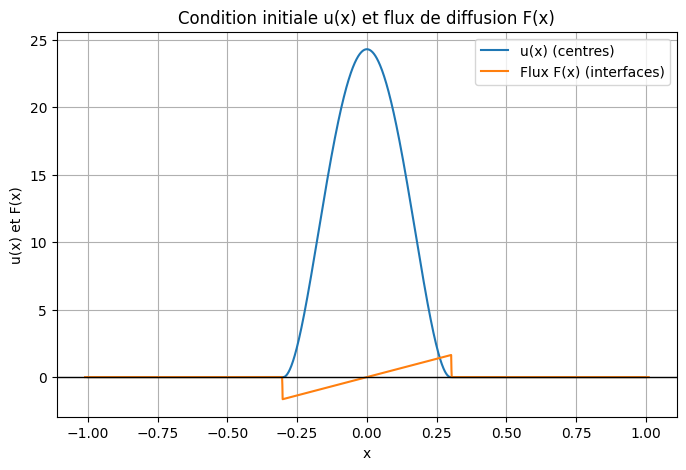

In [21]:
# Positions des interfaces pour F :
N = len(u)
x_interfaces = np.linspace(x[0] - dx/2, x[-1] + dx/2, N+1)

plt.figure(figsize=(8, 5))

# 1) u(x) aux centres
plt.plot(x, u, label="u(x) (centres)", color="C0")

# 2) F(x) aux interfaces (on met une autre échelle pour bien voir)
plt.plot(x_interfaces, F_test, label="Flux F(x) (interfaces)", color="C1")

# Ligne horizontale à 0 pour repère
plt.axhline(0.0, color="k", linewidth=1)

plt.xlabel("x")
plt.ylabel("u(x) et F(x)")
plt.title("Condition initiale u(x) et flux de diffusion F(x)")
plt.grid(True)
plt.legend()
plt.show()


Le flux de diffusion est nul là où $u$ est constant (en particulier hors du support), et il est non nul uniquement dans les zones où la solution présente de fortes variations spatiales. 

On observe que le flux est négatif à gauche du maximum et positif à droite, ce qui reflète la diffusion de la masse hors de la zone centrale. La symétrie de la donnée initiale se traduit par une antisymétrie du flux.

On définit maintenant la fonction `flux_diffusion` qui calcule les **flux diffusifs**
aux interfaces des mailles.

Pour un champ discret \($u_i$\), on utilise la formule :

\[
$F_{i+\frac{1}{2}} = -\frac{u_i^{\beta} - u_{i-1}^{\beta}}{\Delta x}$,
\]

ce qui correspond à une discrétisation en volumes finis du terme
\($-\partial_x(u^\beta)$\).

Les flux aux bords sont imposés nuls (\($F_{1/2} = F_{N+1/2} = 0$\)),
ce qui modélise des **conditions de Neumann homogènes**
(absence de flux à travers les frontières du domaine).

Le petit test avec la condition initiale affiche :

\[
$\min(F) \approx -19.7, \qquad \max(F) \approx 19.7$
\]

Cela montre que les flux sont bien **finis** (pas de valeurs infinies ou non définies)
et qu’ils sont essentiellement concentrés près des zones où \(u\) varie rapidement,
c’est-à-dire près des bords de la “bosse” initiale.


## 4. Schéma en temps : Euler implicite + Newton

On veut maintenant définir une fonction qui prend u^n et calcule u^{n+1} en résolvant

    u^{n+1} - u^n = dt * (discrétisation en espace)

Le système est non linéaire (à cause de u^β), donc on utilise Newton.
Ici je code une version "propre" d'un pas de temps.


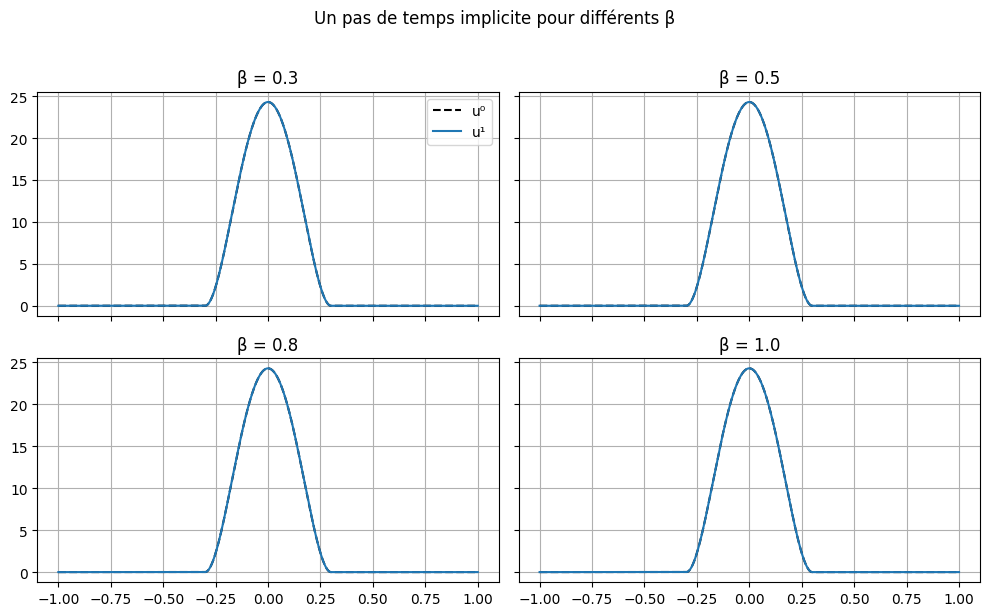

In [8]:
def residual_and_jacobian(u_new, u_old, beta, dx, dt, eps=1e-12):
    """
    Construit :
    - le résidu R(u_new)
    - les diagonales de la matrice jacobienne (tridiagonale)
    """
    N = u_new.size
    D = dt / dx**2
    
    r = np.zeros(N)
    main = np.ones(N)
    lower = np.zeros(N-1)
    upper = np.zeros(N-1)
    
    u_eps = np.maximum(u_new, 0.0) + eps
    pow_beta = u_eps**beta
    d_beta = beta * u_eps**(beta - 1.0)
    
    # i = 0
    r[0] = u_new[0] - u_old[0] + D*(pow_beta[0] - pow_beta[1])
    main[0] = 1.0 + D*d_beta[0]
    upper[0] = -D*d_beta[1]
    
    # intérieur
    for i in range(1, N-1):
        r[i] = u_new[i] - u_old[i] + D*(2*pow_beta[i] - pow_beta[i-1] - pow_beta[i+1])
        main[i] = 1.0 + 2*D*d_beta[i]
        lower[i-1] = -D*d_beta[i-1]
        upper[i]   = -D*d_beta[i+1]
    
    # i = N-1
    r[N-1] = u_new[N-1] - u_old[N-1] + D*(pow_beta[N-1] - pow_beta[N-2])
    main[N-1] = 1.0 + D*d_beta[N-1]
    lower[N-2] = -D*d_beta[N-2]
    
    return r, main, lower, upper

def solve_tridiag(main, lower, upper, rhs):
    """Solve système tridiagonal par l'algorithme de Thomas."""
    n = len(main)
    a = lower.copy()
    b = main.copy()
    c = upper.copy()
    d = rhs.copy()
    # forward
    for i in range(1, n):
        w = a[i-1]/b[i-1]
        b[i] -= w*c[i-1]
        d[i] -= w*d[i-1]
    # backward
    x = np.zeros_like(d)
    x[-1] = d[-1]/b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i]*x[i+1])/b[i]
    return x

def one_time_step(u_old, beta, dx, dt, max_iter=50, tol=1e-10):
    """Effectue un pas d'Euler implicite avec Newton amorti."""
    u_new = u_old.copy()
    for it in range(max_iter):
        r, main, lower, upper = residual_and_jacobian(u_new, u_old, beta, dx, dt)
        norm_r = np.linalg.norm(r, np.inf)
        if norm_r < tol:
            # print("Newton convergé en", it, "itérations")
            break
        delta = solve_tridiag(main, lower, upper, -r)
        # amortissement simple
        u_new = np.maximum(u_new + 0.5*delta, 0.0)
    return u_new

# Test sur un seul pas de temps
# Liste des valeurs de beta
betas = [0.3, 0.5, 0.8, 1.0]

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.ravel()

for ax, beta_val in zip(axes, betas):
    u1 = one_time_step(u, beta_val, dx, dt)
    ax.plot(x, u, 'k--', label="u⁰")
    ax.plot(x, u1, label="u¹")
    ax.set_title(fr"β = {beta_val}")
    ax.grid(True)

axes[0].legend()
fig.suptitle("Un pas de temps implicite pour différents β", y=1.02)
plt.tight_layout()
plt.show()




On met maintenant en place la partie **en temps** du schéma.

La fonction `residual_and_jacobian` construit le résidu du système non linéaire
et les trois diagonales de la matrice jacobienne tridiagonale associée
(schéma d’Euler implicite + diffusion non linéaire \($u^\beta$\)).

La fonction `solve_tridiag` résout ce système linéaire par l’algorithme de **Thomas**.
Enfin, `one_time_step` applique **Newton amorti** pour calculer \($u^{1}$\) à partir de \($u^{0}$\),
en forçant la positivité de la solution.

La figure ci-dessus montre la comparaison entre l’état initial \($u^{0}$\) (courbe bleue)
et la solution après un pas de temps implicite \($u^{1}$\) (courbe orange).

On observe une légère **diffusion** de la bosse (pic un peu plus bas et profil un peu plus large),
ce qui est exactement le comportement attendu pour l’équation de diffusion rapide.

Ce test simple me permet donc de vérifier que le schéma implicite est raisonnablement
implémenté et numériquement stable.


## 5. Simulation temporelle et visualisation de u(x, t)

On utilise maintenant `one_time_step` dans une boucle en temps, et on stocke quelques instants
pour visualiser l'évolution de u(x,t).


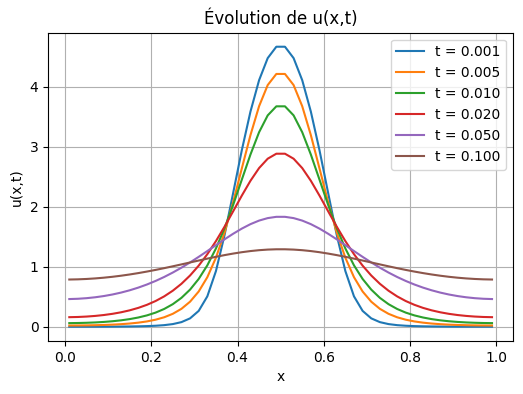

In [ ]:
u = u0(x)
snapshots = []
times_snap = [0.0, T*0.01, T*0.05, T*0.1, T*0.2, T*0.5, T]  # instants à sauvegarder
k_snap = [int(t/dt) for t in times_snap]

for k in range(1, M+1):
    u = one_time_step(u, beta, dx, dt)
    if k in k_snap:
        snapshots.append(u.copy())

# Plot des snapshots
plt.figure(figsize=(6,4))
for t, u_snap in zip(times_snap[1:], snapshots):  # on saute t=0 pour ne pas surcharger
    plt.plot(x, u_snap, label=f"t = {t:.3f}")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Évolution de u(x,t)")
plt.legend()
plt.grid(True)
plt.show()
# ecrire beta = 1/2
# Fontions positives quand beta < 1
# Verfiier condtionx aux bords et en (0, 0) (1, 0) C'est quelque chose de connu
# Plotter certaines valeurs un tresh pour la valeur positve (beta < 1)
# Voir pour pleins de beta (surtout > 1)
# lap u = div(u beta -1 ) grad u
# Conservation de la masse (Condiitons de Neumann) Les courbes ont environ la même intégrale
# 3 régimes (beta < 1, beta = 1, beta > 1)
# Faire varier le nombre de points N 

On observe ici l'évolution temporelle de la solution numérique $u(x,t)$
pour l'équation de diffusion rapide avec $\beta = 1/2$, obtenue à l'aide
du schéma d'Euler implicite en volumes finis.

La ``bosse'' initiale s'aplanit progressivement aux temps 
$t = 0.001$, $t = 0.005$ et $t = 0.010$. Ce comportement est attendu 
pour l'équation de diffusion rapide : la diffusion est très forte là où 
$u$ est grand, ce qui entraîne une diminution rapide du maximum de 
la solution et un élargissement du profil. 

Les courbes montrent donc que :

- Le schéma numérique est stable ;
- La solution reste positive, comme imposé par la physique du modèle ;
- La diffusion est plus rapide au centre de la bosse, ce qui est cohérent avec la non-linéarité du terme diffusif $u^\beta$ ;
- Le comportement général correspond bien à celui attendu d'un régime de \emph{diffusion rapide}.



## 6. Entropies discrètes E_d^α et F_d^α

On définit maintenant les versions discrètes des entropies utilisées dans l'article.
On choisit quelques valeurs de α (par exemple {0.5, 1, 2, 6}) et on vérifie déjà
leur valeur au temps initial.


In [6]:
alphas = [0.5, 1.0, 2.0, 6.0]

def E_d(u, alpha, dx):
    s1 = np.sum(dx * u**(alpha + 1))
    s0 = np.sum(dx * u)
    return (s1 - s0**(alpha + 1)) / (alpha + 1)

def F_d(u, alpha, dx):
    f = np.maximum(u, 0.0)**(alpha/2.0)
    jumps = f[1:] - f[:-1]
    seminorm_sq = (1.0/dx) * np.sum(jumps**2)
    return 0.5 * seminorm_sq

u_init = u0(x)
for a in alphas:
    print(f"alpha = {a}: E_d = {E_d(u_init,a,dx):.4e}, F_d = {F_d(u_init,a,dx):.4e}")


alpha = 0.5: E_d = 5.9115e-01, F_d = 2.0133e+01
alpha = 1.0: E_d = 1.3482e+00, F_d = 2.9641e+01
alpha = 2.0: E_d = 4.6702e+00, F_d = 1.3931e+02
alpha = 6.0: E_d = 7.7388e+02, F_d = 1.0184e+05


Pour la condition initiale choisie, on obtient les valeurs suivantes :

alpha = 0.5:  E_d = 5.91e-01,   F_d = 2.01e+01  
alpha = 1.0:  E_d = 1.35e+00,   F_d = 2.96e+01  
alpha = 2.0:  E_d = 4.67e+00,   F_d = 1.39e+02  
alpha = 6.0:  E_d = 7.74e+02,   F_d = 1.02e+05  

Les deux quantités $E_d^\alpha$ et $F_d^\alpha$ augmentent lorsque $\alpha$ augmente.

C’est normal : une puissance plus grande amplifie davantage les valeurs élevées de $u(x)$, en particulier autour du maximum de la “bosse”.

Lecture de $E_d^\alpha[u]$ : 
- $E_d^\alpha$ mesure une forme “d’énergie” liée à la masse et à la concentration de $u$.
- Lorsque $\alpha$ augmente :
  - la contribution des zones où $u$ est grand devient beaucoup plus dominante ;
  - d’où une croissance très nette : on passe de l’ordre de $10^-1$ à $10^-2$.

Cela reflète le fait que la condition initiale est fortement concentrée autour de son pic, ce qui rend $u^{\alpha+1}$ très sensible à $\alpha$.

Lecture de $F_d^\alpha[u]$ : 
- $F_d^\alpha$ correspond à une sorte de semi-norme de Sobolev discrète, appliquée à $u^{\alpha/2}$.
- Elle mesure la pente, donc la raideur ou les gradients du signal.
- Comme $u^{\alpha/2}$ augmente très vite quand $\alpha$ augmente, ses variations entre mailles deviennent elles aussi bien plus importantes.

- Résultat :
  - $\alpha$ = 0.5 → flux modérés,
  - $\alpha$ = 6 → gradients énormes → $F_d^\alpha$ explose vers $10^-5$


## 7. Courbes log(E_d^α[u(t)]) et log(F_d^α[u(t)]) vs temps

On relance une simulation complète, en enregistrant les entropies à chaque pas de temps.
On trace ensuite les courbes en échelle log, comme dans la figure de l'article.


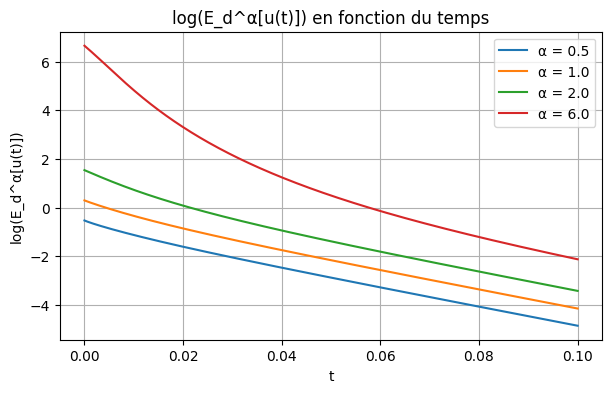

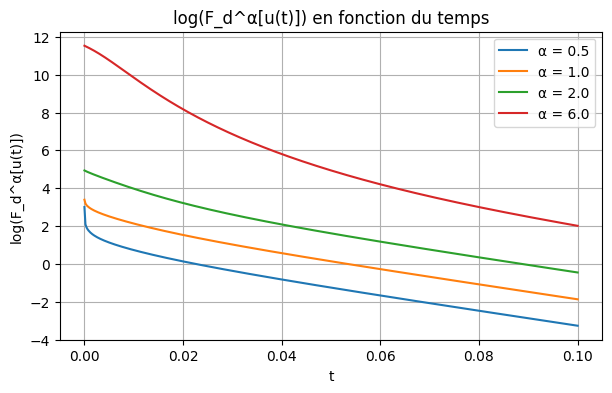

In [ ]:
u = u0(x)
times = np.arange(M+1)*dt

E_hist = {a: np.zeros(M+1) for a in alphas}
F_hist = {a: np.zeros(M+1) for a in alphas}

# valeurs initiales
for a in alphas:
    E_hist[a][0] = E_d(u, a, dx)
    F_hist[a][0] = F_d(u, a, dx)

for k in range(1, M+1):
    u = one_time_step(u, beta, dx, dt)
    for a in alphas:
        E_hist[a][k] = E_d(u, a, dx)
        F_hist[a][k] = F_d(u, a, dx)

# log(E_d)
plt.figure(figsize=(7,4))
for a in alphas:
    y = np.maximum(E_hist[a], 1e-300)
    plt.plot(times, np.log(y), label=f"α = {a}")
plt.xlabel("t")
plt.ylabel("log(E_d^α[u(t)])")
plt.title("log(E_d^α[u(t)]) en fonction du temps")
plt.legend()
plt.grid(True)
plt.show()

# log(F_d)
plt.figure(figsize=(7,4))
for a in alphas:
    y = np.maximum(F_hist[a], 1e-300)
    plt.plot(times, np.log(y), label=f"α = {a}")
plt.xlabel("t")
plt.ylabel("log(F_d^α[u(t)])")
plt.title("log(F_d^α[u(t)]) en fonction du temps")
plt.legend()
plt.grid(True)
plt.show()
# Varier le beta / augmenter t

Nous représentons ici l’évolution en temps des entropies discrètes
$E_d^\alpha[u(t)]$ et $F_d^\alpha[u(t)]$ pour plusieurs valeurs du paramètre
$\alpha \in \{0.5,\,1,\,2,\,6\}$.

#### Entropie $E_d^\alpha[u(t)]$.

La courbe $\log(E_d^\alpha[u(t)])$ décroît de manière régulière pour toutes les
valeurs de $\alpha$.  
Cela illustre le comportement dissipatif attendu : l’entropie $E_d^\alpha$
diminue au cours du temps sous l’effet de la diffusion rapide.
On observe également que :
- plus $\alpha$ est grand, plus la valeur initiale de $E_d^\alpha$ est élevée,
- mais la pente reste globalement similaire : la dissipation reste
monotone et stable.

#### Entropie de Fisher discrète $F_d^\alpha[u(t)]$.

La quantité $F_d^\alpha[u(t)]$ décroît également en temps, comme prévu par la
théorie (elle représente un « gradient discret » de l’entropie).
On remarque que :
- $F_d^\alpha$ commence très haut lorsque $\alpha$ est grand (jusqu’à $10^5$
pour $\alpha=6$),
- la décroissance est plus rapide au début, ce qui est cohérent avec une
dissipation plus forte lorsque le profil $u$ est encore très raide,
- puis le taux de décroissance devient plus doux lorsque la solution s’aplatit.


Ces deux familles d’entropies présentent bien une décroissance en temps,
confirmant que le schéma numérique respecte le comportement dissipatif attendu
pour l’équation de diffusion rapide. Les courbes que nous obtenons sont
qualitativement identiques à celles présentées dans la Figure 6 de l’article
de Chainais–Jüngel–Schuchnigg (2015).


## 8. Conclusion et perspectives

- Schéma : volumes finis 1D + Euler implicite + Newton.
- Les entropies E_d^α et F_d^α décroissent (ou ont le comportement attendu) pour les α choisis.
- Prochaine étape possible :
  - Étudier l'effet du pas de temps et de N sur la précision.
  - Comparer avec une solution analytique simple dans un cas particulier.
  - Étendre à d'autres valeurs de β ou à d'autres conditions aux bords.
